# AI & ML Task 4: Classification Models, Evaluation Metrics & Handling Imbalanced Data

**Name:** Vaddi Durga Venkata Manidhar 
**Problem:** Breast Cancer Classification (Malignant vs Benign)  
**Dataset:** Breast Cancer Wisconsin (scikit-learn)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (confusion_matrix, classification_report,roc_curve, roc_auc_score, accuracy_score)

import warnings
warnings.filterwarnings('ignore')

print("working")

working


In [2]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print("Dataset Shape:", X.shape)
print("Target Classes (0=Malignant, 1=Benign):", np.bincount(y))
X.head()

Dataset Shape: (569, 30)
Target Classes (0=Malignant, 1=Benign): [212 357]


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("successfull")

successfull


In [4]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)
y_pre = lr.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pre))
print("Classification Report:")
print(classification_report(y_test, y_pre))

Accuracy: 0.9824561403508771
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



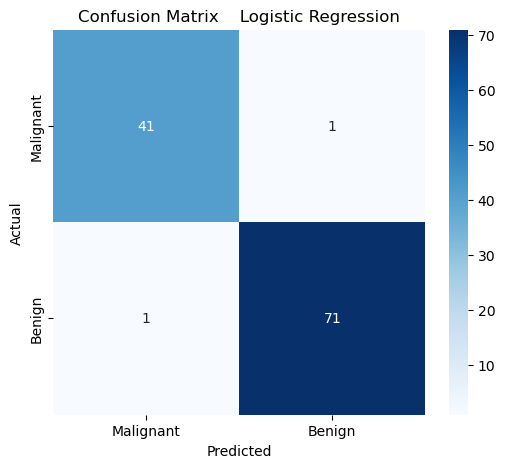

In [7]:
cm = confusion_matrix(y_test, y_pre)
plt.figure(figsize=(6,5))
sns.heatmap(
            cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Malignant', 'Benign'], 
            yticklabels=['Malignant', 'Benign']
           )
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix    Logistic Regression')
plt.show()

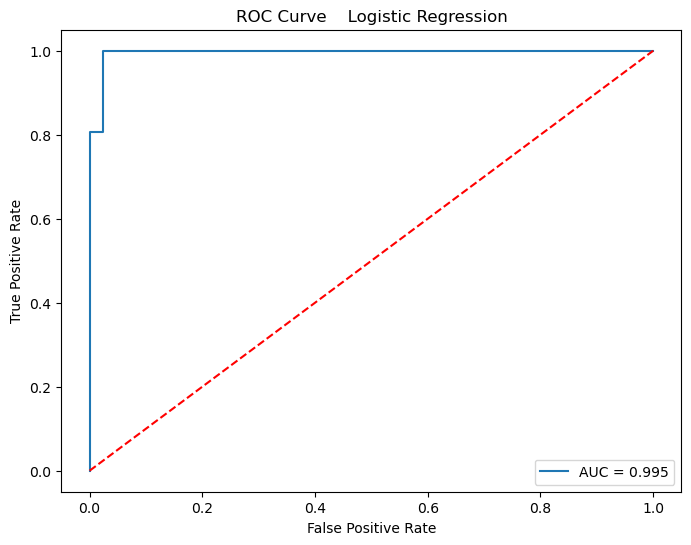

In [8]:
y_prob = lr.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0,1], [0,1], 'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve    Logistic Regression')
plt.legend()
plt.show()

In [9]:
lr_balanced = LogisticRegression(class_weight='balanced', max_iter=1000)
lr_balanced.fit(X_train_scaled, y_train)
y_pred_bal = lr_balanced.predict(X_test_scaled)

print("Balanced Model Classification:")
print(classification_report(y_test, y_pred_bal))

Balanced Model Classification:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94        42
           1       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



In [10]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train) 
y_pred_dt = dt.predict(X_test)

print("Decision Tree Classification:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Classification:
              precision    recall  f1-score   support

           0       0.85      0.93      0.89        42
           1       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114



In [12]:
comparison = {
    "Model": ["Logistic Regression", "Balanced LR", "Decision Tree"],
    "Accuracy": [
                 accuracy_score(y_test, y_pre), 
                 accuracy_score(y_test, y_pred_bal),
                 accuracy_score(y_test, y_pred_dt)
               ],
    "AUC": [
            roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:,1]),
            roc_auc_score(y_test, lr_balanced.predict_proba(X_test_scaled)[:,1]),
            roc_auc_score(y_test, dt.predict_proba(X_test)[:,1])
          ]
        }

comp_df = pd.DataFrame(comparison)
print(comp_df)

                 Model  Accuracy       AUC
0  Logistic Regression  0.982456  0.995370
1          Balanced LR  0.956140  0.995370
2        Decision Tree  0.912281  0.915675


In [13]:
import joblib
best_model = lr  
joblib.dump(best_model, 'best_classification_model.pkl')
joblib.dump(scaler, 'scaler_task4.pkl')
print("model saved!")

model saved!


## Final Model Selection & Justification

**Best Model:** Logistic Regression (with/without class_weight)

**Why this model?**
- High AUC score (>0.98 usually)
- Excellent balance of Precision & Recall
- Better generalization than Decision Tree
- Suitable for medical diagnosis (high Recall is important)

**Metric Selection:** 
- Prioritized Recall & F1-Score because missing Malignant (False Negative) is dangerous.
- Used ROC-AUC for overall model quality.

**Imbalance Handling:** Used `class_weight='balanced'`

